<a href="https://colab.research.google.com/github/HnhanBk415/mliot-pyml-2026-hw/blob/main/week07/Homework_B13/pytorch_emnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bài tập buổi 13: Xây dựng mạng MLP trên EMNIST

Đề bài : Xây dựng pipeline huấn luyện một mạng MLP (Multi-Layer Perceptron) để phân loại **chữ cái in hoa** trong dataset **EMNIST** (A–Z, 26 lớp).

Mục tiêu:
- Tải và chuẩn bị dữ liệu EMNIST bằng `torchvision`.
- Định nghĩa mô hình MLP bằng `nn.Module`.
- Viết vòng lặp huấn luyện và đánh giá.
- Trực quan hóa kết quả và lưu mô hình.

Kết quả tham khảo: MLP đơn giản này thường đạt khoảng **85–90%** accuracy trên tập test.

## 1. Import và cấu hình

Import các thư viện cần thiết rồi đặt các tham số huấn luyện.

Gợi ý: `BATCH_SIZE = 256`, `EPOCHS = 5`, `LEARNING_RATE = 1e-3`. Chọn `DEVICE` là `cuda` nếu có GPU, ngược lại dùng `cpu`.

In [1]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from torchvision import datasets, transforms

BATCH_SIZE = 256
EPOCHS = 5
LEARNING_RATE = 1e-3
DATA_DIR = './data'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(0)

print(f'PyTorch: {torch.__version__}')
print(f'Thiết bị: {DEVICE}')

PyTorch: 2.11.0+cu128
Thiết bị: cuda


## 2. Dataset và DataLoader

Tải dataset EMNIST với `split='letters'` (26 lớp chữ cái in hoa A–Z, ảnh xám 28×28).

- Dùng `transforms.Compose([transforms.ToTensor()])` để đổi ảnh thành tensor.
- Tách tập train gốc (124.800 mẫu) thành **100.000 mẫu train** và **24.800 mẫu validation**.
- Tạo 3 `DataLoader` với `batch_size=BATCH_SIZE`; chỉ `train_loader` cần `shuffle=True`.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

full_train = datasets.EMNIST(DATA_DIR, split='letters', train=True, transform=transform, download=True)
test_set = datasets.EMNIST(DATA_DIR, split='letters', train=False, transform=transform, download=True)

# TODO: dùng random_split tách full_train thành train_set (100.000) và val_set (24.800)
# TODO: tạo train_loader, val_loader, test_loader với batch_size=BATCH_SIZE
full_train = datasets.EMNIST(
    DATA_DIR,
    split='letters',
    train=True,
    transform=transform,
    target_transform=lambda y: y - 1,
    download=True
)

test_set = datasets.EMNIST(
    DATA_DIR,
    split='letters',
    train=False,
    transform=transform,
    target_transform=lambda y: y - 1,
    download=True
)

train_set, val_set = random_split(
    full_train,
    [100000, 24800]
)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)
print(len(train_set), len(val_set), len(test_set))

100%|██████████| 562M/562M [00:07<00:00, 74.7MB/s]


100000 24800 20800


## 3. Khám phá dữ liệu

In shape của một batch rồi vẽ vài ảnh đầu tiên để xem dữ liệu trông như thế nào.

Lưu ý: nhãn là số nguyên 0–25, tương ứng với chữ cái A–Z. Có thể đổi sang ký tự bằng `chr(nhãn + ord('A'))`.

In [3]:
batch_images, batch_labels = next(iter(train_loader))
print('Batch ảnh :', batch_images.shape)
print('Batch nhãn:', batch_labels.shape)

# TODO: vẽ 10 ảnh đầu tiên của batch (cmap='gray'), tiêu đề mỗi ảnh là nhãn dạng chữ cái
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image = batch_images[i].squeeze()
    label = batch_labels[i].item()

    letter = chr(label + ord('A'))

    ax.imshow(image, cmap='gray')
    ax.set_title(f'Label: {letter}')
    ax.axis('off')

plt.tight_layout()
plt.show()

Batch ảnh : torch.Size([256, 1, 28, 28])
Batch nhãn: torch.Size([256])


## 4. Định nghĩa MLP

Xây dựng lớp `EMNISTMLP` kế thừa `nn.Module`.

Gợi ý cấu trúc: `Flatten` → `Linear(784, 128)` → `ReLU` → `Linear(128, 26)`.
Chú ý: 784 = 28×28 (kích thước ảnh sau khi dẹt), 26 = số lớp chữ cái.

In [4]:
class EMNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: định nghĩa các layer
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 26)
        )
    def forward(self, images):
        # TODO: cho images đi qua các layer
        return self.network(images)

model = EMNISTMLP().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

print(model)

EMNISTMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=26, bias=True)
  )
)


## 5. Vòng lặp huấn luyện và đánh giá

Viết 2 hàm:

- `train_one_epoch`: với mỗi batch, thực hiện `zero_grad` → forward → tính loss → `backward` → `step`. Cộng dồn loss và số dự đoán đúng.
- `evaluate`: giống vòng lặp trên nhưng **không cập nhật trọng số**, dùng `model.eval()` và `torch.no_grad()`.

Cả hai hàm trả về `(loss trung bình, accuracy)`.

In [10]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Xóa gradient cũ
        optimizer.zero_grad()

        # Forward
        logits = model(images)

        # Tính loss
        loss = criterion(logits, labels)

        # Backpropagation
        loss.backward()

        # Cập nhật trọng số
        optimizer.step()

        # Cộng dồn loss
        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size

        # Lấy class có logit lớn nhất
        predictions = logits.argmax(dim=1)

        total_correct += (predictions == labels).sum().item()
        total_samples += batch_size

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return avg_loss, accuracy

def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model(images)

            loss = criterion(logits, labels)

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size

            predictions = logits.argmax(dim=1)

            total_correct += (predictions == labels).sum().item()
            total_samples += batch_size

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return avg_loss, accuracy


## 6. Huấn luyện

Chạy vòng lặp qua `EPOCHS` epoch. Mỗi epoch: train 1 epoch trên `train_loader`, đánh giá trên `val_loader`, lưu loss/accuracy vào các list và in kết quả.

In [11]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(1, EPOCHS + 1):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f'Epoch {epoch}: '
        f'train loss={train_loss:.4f}, '
        f'val loss={val_loss:.4f}, '
        f'train acc={train_accuracy:.2%}, '
        f'val acc={val_accuracy:.2%}'
    )

Epoch 1: train loss=1.2334, val loss=0.8672, train acc=66.31%, val acc=75.40%
Epoch 2: train loss=0.7318, val loss=0.6605, train acc=79.09%, val acc=80.78%
Epoch 3: train loss=0.5755, val loss=0.5512, train acc=83.36%, val acc=83.72%
Epoch 4: train loss=0.4918, val loss=0.4888, train acc=85.55%, val acc=85.43%
Epoch 5: train loss=0.4393, val loss=0.4567, train acc=86.89%, val acc=86.25%


## 7. Đánh giá và trực quan hóa

1. Vẽ 2 biểu đồ cạnh nhau: **Loss** và **Accuracy** theo epoch (so sánh train vs val).
2. Đánh giá mô hình trên `test_loader` (tập chưa từng dùng khi huấn luyện).
3. Lấy 1 batch từ `test_loader`, vẽ 10 ảnh với nhãn thật và nhãn dự đoán (xanh = đúng, đỏ = sai).

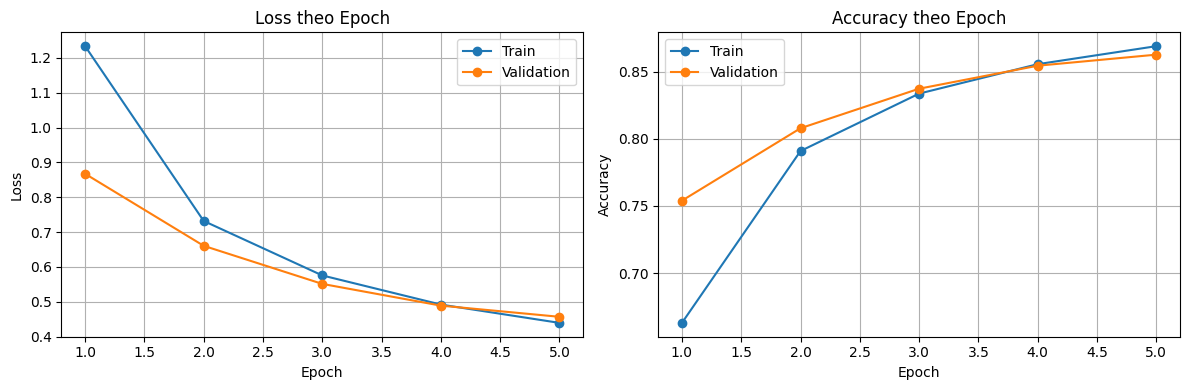

In [12]:
epochs = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs, train_losses, marker='o', label='Train')
axes[0].plot(epochs, val_losses, marker='o', label='Validation')

axes[0].set_title('Loss theo Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs, train_accuracies, marker='o', label='Train')
axes[1].plot(epochs, val_accuracies, marker='o', label='Validation')

axes[1].set_title('Accuracy theo Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    criterion
)

print(
    f'Test loss={test_loss:.4f}, '
    f'test accuracy={test_accuracy:.2%}'
)

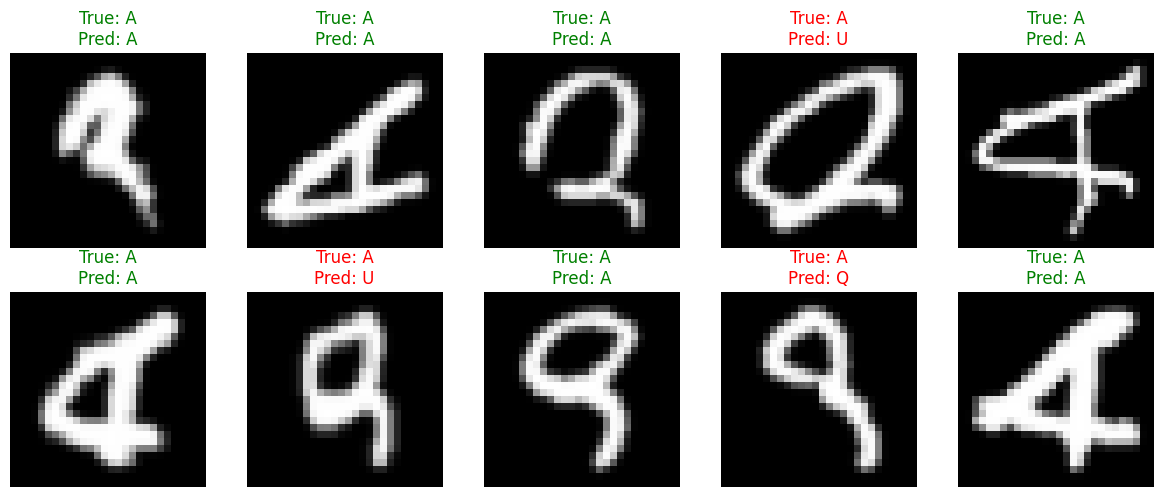

In [13]:
# vẽ 10 dự đoán trên test
test_images, test_labels = next(iter(test_loader))

model.eval()

with torch.no_grad():
    logits = model(test_images.to(DEVICE))
    predictions = logits.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image = test_images[i].squeeze()

    true_label = test_labels[i].item()
    pred_label = predictions[i].item()

    true_letter = chr(true_label + ord('A'))
    pred_letter = chr(pred_label + ord('A'))

    is_correct = true_label == pred_label

    color = 'green' if is_correct else 'red'

    ax.imshow(image, cmap='gray')

    ax.set_title(
        f'True: {true_letter}\nPred: {pred_letter}',
        color=color
    )

    ax.axis('off')

plt.tight_layout()
plt.show()

## 8. Lưu mô hình

Lưu trọng số của mô hình bằng `state_dict` để dùng lại sau này.

In [14]:
# TODO: lưu state_dict của model vào file 'emnist_mlp.pt'
torch.save(
    model.state_dict(),
    'emnist_mlp.pt'
)

print('Đã lưu model vào emnist_mlp.pt')

Đã lưu model vào emnist_mlp.pt
